Імпорт бібліотек

In [5]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import timeit as ti
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import OneHotEncoder
from matplotlib.colors import ListedColormap 

Завантаження датасету

In [7]:
# Завантаження датасету
power_dataset_raw = fetch_ucirepo(id=235) 

# Основні дані
features_data_raw = power_dataset_raw.data.features 
df_power_raw = pd.DataFrame(features_data_raw)

df_power_raw.to_csv('household_power_consumption.csv', index=False)

D:\anaconda3\Lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Створимо Pandas DataFrame

In [9]:
# Зчитування CSV-файлу
df_power_clean = pd.read_csv('household_power_consumption.csv', delimiter=',', na_values='?', header=0, dtype={
    "Date": str,
    "Time": str,
    "Global_active_power": float,
    "Global_reactive_power": float,
    "Voltage": float,
    "Global_intensity": float,
    "Sub_metering_1": float,
    "Sub_metering_2": float,
    "Sub_metering_3": float
})

# Об’єднання дати і часу
df_power_clean['Datetime_combined'] = pd.to_datetime(df_power_clean['Date'] + ' ' + df_power_clean['Time'], format='%d/%m/%Y %H:%M:%S')
df_power_clean.drop(['Date', 'Time'], axis=1, inplace=True)
df_power_clean.insert(0, 'Datetime_combined', df_power_clean.pop('Datetime_combined'))

df_power_clean.dropna(inplace=True)

print(df_power_clean.head())

    Datetime_combined  Global_active_power  Global_reactive_power  Voltage  \
0 2006-12-16 17:24:00                4.216                  0.418   234.84   
1 2006-12-16 17:25:00                5.360                  0.436   233.63   
2 2006-12-16 17:26:00                5.374                  0.498   233.29   
3 2006-12-16 17:27:00                5.388                  0.502   233.74   
4 2006-12-16 17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  


Створимо NumPy Array на основі Pandas DataFrame

In [11]:
# NumPy-масив
power_array = df_power_clean.to_numpy()

# Індекси колонок
IDX_DATETIME = 0
IDX_GLOB_ACT_PWR = 1
IDX_GLOB_REACT_PWR = 2
IDX_VOLTAGE = 3
IDX_INTENSITY = 4
IDX_SUB_1 = 5
IDX_SUB_2 = 6
IDX_SUB_3 = 7

print(df_power_clean.columns)
print(power_array[:5])

Index(['Datetime_combined', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')
[[Timestamp('2006-12-16 17:24:00') 4.216 0.418 234.84 18.4 0.0 1.0 17.0]
 [Timestamp('2006-12-16 17:25:00') 5.36 0.436 233.63 23.0 0.0 1.0 16.0]
 [Timestamp('2006-12-16 17:26:00') 5.374 0.498 233.29 23.0 0.0 2.0 17.0]
 [Timestamp('2006-12-16 17:27:00') 5.388 0.502 233.74 23.0 0.0 1.0 17.0]
 [Timestamp('2006-12-16 17:28:00') 3.666 0.528 235.68 15.8 0.0 1.0 17.0]]


Завдання першого рівня

1. Обрати всі записи, у яких загальна активна споживана потужність
перевищує 5 кВт.

In [15]:
# Потужність > 5 кВт
def filter_high_power_df(dataframe):
    return dataframe[dataframe['Global_active_power'] > 5]

def filter_high_power_np(array):
    return array[array[:, IDX_GLOB_ACT_PWR] > 5]

# Вивід
def print_df_result(func, arg):
    print("Pandas DataFrame")
    print(func(arg).head())
    exec_time = ti.timeit(lambda: func(arg), number=1)
    print(f"Pandas DataFrame filter time: {exec_time} seconds")

def print_np_result(func, arg):
    print("NumPy Array")
    print(func(arg))
    exec_time = ti.timeit(lambda: func(arg), number=1)
    print(f"NumPy Array filter time: {exec_time} seconds")

print_df_result(filter_high_power_df, df_power_clean)
print("\n")
print_np_result(filter_high_power_np, power_array)

Pandas DataFrame
     Datetime_combined  Global_active_power  Global_reactive_power  Voltage  \
1  2006-12-16 17:25:00                5.360                  0.436   233.63   
2  2006-12-16 17:26:00                5.374                  0.498   233.29   
3  2006-12-16 17:27:00                5.388                  0.502   233.74   
11 2006-12-16 17:35:00                5.412                  0.470   232.78   
12 2006-12-16 17:36:00                5.224                  0.478   232.99   

    Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
1               23.0             0.0             1.0            16.0  
2               23.0             0.0             2.0            17.0  
3               23.0             0.0             1.0            17.0  
11              23.2             0.0             1.0            17.0  
12              22.4             0.0             1.0            16.0  
Pandas DataFrame filter time: 0.005279900040477514 seconds


NumPy Array
[[Timesta

2. Обрати всі записи, у яких вольтаж перевищую 235 В.

In [17]:
# Вольтаж > 235
def filter_high_voltage_df(dataframe):
    return dataframe[dataframe['Voltage'] > 235]

def filter_high_voltage_np(array):
    return array[array[:, IDX_VOLTAGE] > 235]

print_df_result(filter_high_voltage_df, df_power_clean)
print("\n")
print_np_result(filter_high_voltage_np, power_array)


Pandas DataFrame
     Datetime_combined  Global_active_power  Global_reactive_power  Voltage  \
4  2006-12-16 17:28:00                3.666                  0.528   235.68   
5  2006-12-16 17:29:00                3.520                  0.522   235.02   
6  2006-12-16 17:30:00                3.702                  0.520   235.09   
7  2006-12-16 17:31:00                3.700                  0.520   235.22   
14 2006-12-16 17:38:00                4.054                  0.422   235.24   

    Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
4               15.8             0.0             1.0            17.0  
5               15.0             0.0             2.0            17.0  
6               15.8             0.0             1.0            17.0  
7               15.8             0.0             1.0            17.0  
14              17.6             0.0             1.0            17.0  
Pandas DataFrame filter time: 0.18141489988192916 seconds


NumPy Array
[[Timestam

3. Обрати всі записи, у яких сила струму лежить в межах 19-20 А,
для них виявити ті, у яких пральна машина та холодильних
споживають більше, ніж бойлер та кондиціонер.

In [19]:
# Сила струму в межах 19-20 А, і група 2 > групи 3
def filter_SM2_gt_SM3_df(dataframe):
    filtered_df = dataframe[(dataframe['Global_intensity'] >= 19) & (dataframe['Global_intensity'] <= 20)]
    return filtered_df[filtered_df['Sub_metering_2'] > filtered_df['Sub_metering_3']]

def filter_SM2_gt_SM3_np(array):
    in_range = array[(array[:, IDX_INTENSITY] >= 19) & (array[:, IDX_INTENSITY] <= 20)]
    return in_range[in_range[:, IDX_SUB_2] > in_range[:, IDX_SUB_3]]

print_df_result(filter_SM2_gt_SM3_df, df_power_clean)
print("\n")
print_np_result(filter_SM2_gt_SM3_np, power_array)

Pandas DataFrame
      Datetime_combined  Global_active_power  Global_reactive_power  Voltage  \
45  2006-12-16 18:09:00                4.464                  0.136   234.66   
460 2006-12-17 01:04:00                4.582                  0.258   238.08   
464 2006-12-17 01:08:00                4.618                  0.104   239.61   
475 2006-12-17 01:19:00                4.636                  0.140   237.37   
476 2006-12-17 01:20:00                4.634                  0.152   237.17   

     Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
45               19.0             0.0            37.0            16.0  
460              19.6             0.0            13.0             0.0  
464              19.6             0.0            27.0             0.0  
475              19.4             0.0            36.0             0.0  
476              19.4             0.0            35.0             0.0  
Pandas DataFrame filter time: 0.010472000110894442 seconds


NumPy Arr

4. Обрати випадковим чином 500000 записів (без повторів елементів
вибірки), для них обчислити середні величини усіх 3-х груп
споживання електричної енергії

In [21]:
# Випадкова вибірка 500000 записів, обчислити середнє
def sample_mean_df(dataframe):
    sample_df = dataframe.sample(n=500000, replace=False)
    return sample_df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].mean()

def sample_mean_np(array):
    sampled_arr = array[np.random.choice(array.shape[0], 500000, replace=False)]
    return np.mean(sampled_arr[:, IDX_SUB_1:IDX_SUB_3+1], axis=0)

print_df_result(sample_mean_df, df_power_clean)
print("\n")
print_np_result(sample_mean_np, power_array)

Pandas DataFrame
Sub_metering_1    1.116492
Sub_metering_2    1.300728
Sub_metering_3    6.458752
dtype: float64
Pandas DataFrame filter time: 0.18169109988957644 seconds


NumPy Array
[1.115672 1.283144 6.468416]
NumPy Array filter time: 0.5889959998894483 seconds


5. Обрати ті записи, які після 18-00 споживають понад 6 кВт за
хвилину в середньому, серед відібраних визначити ті, у яких
основне споживання електроенергії у вказаний проміжок часу
припадає на пральну машину, сушарку, холодильник та освітлення
(група 2 є найбільшою), а потім обрати кожен третій результат із
першої половини та кожен четвертий результат із другої половини.

In [23]:
# Складна фільтрація з часом, потужністю і підгрупами
def advanced_selection_df(dataframe):
    after_6pm = dataframe[dataframe['Datetime_combined'].dt.hour >= 18]
    over_6kw = after_6pm[after_6pm['Global_active_power'] + after_6pm['Global_reactive_power'] > 6]

    dominant_group2 = over_6kw[
        (over_6kw['Sub_metering_2'] > over_6kw['Sub_metering_1']) &
        (over_6kw['Sub_metering_2'] > over_6kw['Sub_metering_3'])
    ]

    half_len = len(dominant_group2) // 2
    part1 = dominant_group2[:half_len]
    part2 = dominant_group2[half_len:]

    third_from_first = part1[::3]
    fourth_from_second = part2[::4]

    return pd.concat([third_from_first, fourth_from_second])

def advanced_selection_np(array):
    hours_arr = np.array([dt.hour for dt in array[:, IDX_DATETIME]])
    after_6pm = array[hours_arr >= 18]

    over_6kw = after_6pm[after_6pm[:, IDX_GLOB_ACT_PWR] + after_6pm[:, IDX_GLOB_REACT_PWR] > 6]

    dominant_group2 = over_6kw[
        (over_6kw[:, IDX_SUB_2] > over_6kw[:, IDX_SUB_1]) &
        (over_6kw[:, IDX_SUB_2] > over_6kw[:, IDX_SUB_3])
    ]

    half_len = len(dominant_group2) // 2
    part1 = dominant_group2[:half_len]
    part2 = dominant_group2[half_len:]

    third_from_first = part1[::3]
    fourth_from_second = part2[::4]

    return np.concatenate((third_from_first, fourth_from_second), axis=0)

print_df_result(advanced_selection_df, df_power_clean)
print("\n")
print_np_result(advanced_selection_np, power_array)

Pandas DataFrame
        Datetime_combined  Global_active_power  Global_reactive_power  \
41    2006-12-16 18:05:00                6.052                  0.192   
44    2006-12-16 18:08:00                6.308                  0.116   
4495  2006-12-19 20:19:00                5.586                  0.424   
17497 2006-12-28 21:01:00                7.062                  0.270   
17500 2006-12-28 21:04:00                7.376                  0.238   

       Voltage  Global_intensity  Sub_metering_1  Sub_metering_2  \
41      232.93              26.2             0.0            37.0   
44      232.25              27.0             0.0            36.0   
4495    236.01              23.8             0.0            35.0   
17497   235.76              30.2             2.0            65.0   
17500   234.67              31.4             1.0            72.0   

       Sub_metering_3  
41               17.0  
44               17.0  
4495              0.0  
17497            17.0  
17500          

Висновки
Для роботи з табличними даними я б обрав Pandas DataFrame, оскільки він зручніший у використанні й спочатку створений саме для обробки датасетів. В ньому все інтуїтивно: колонки мають назви, легко відбирати потрібні дані, працювати з пропущеними значеннями, фільтрацією, групуванням і так далі.
NumPy Array теж має свої переваги, особливо коли йдеться про великі масиви чисел і математичні обчислення - з цим він справляється швидше і краще. Але для роботи з табличними даними - це не найзручніший варіант. Колонки не мають назв. Щоб додати назви - потрібно створювати окрему структуру (словник або список), і при цьому назви не інтегруються в сам масив. Якщо зробити назви першим рядком, потім доводиться постійно обходити його в коді.
Працювати доводиться через індекси, а не назви колонок. При виведенні через print() - NumPy обрізає дані: показує по 3 перші та 3 останні колонки/рядки. У DataFrame видно перші та останні 5 рядків, і всі назви колонок, що набагато зручніше для аналізу. Видалення або заміна NaN - це ще один квест. У DataFrame це одна функція (dropna(), fillna()), а в NumPy треба враховувати типи, структуру, місця пропусків - усе вручну.
Не підтримує різні типи даних в одній "таблиці". У Pandas це не проблема - там можуть бути і числа, і дати, і текст.

Завдання другого рівня

Завантаження датасету

In [31]:
auto_data = fetch_ucirepo(id=10)
features_df = pd.DataFrame(auto_data.data.features)

# Збереження до CSV
features_df.to_csv('auto_dataset.csv', index=False)

# Читання CSV
raw_df = pd.read_csv('auto_dataset.csv')
print(raw_df)

array_data = raw_df.to_numpy()
print(array_data)

       price  highway-mpg  city-mpg  peak-rpm  horsepower  compression-ratio  \
0    13495.0           27        21    5000.0       111.0                9.0   
1    16500.0           27        21    5000.0       111.0                9.0   
2    16500.0           26        19    5000.0       154.0                9.0   
3    13950.0           30        24    5500.0       102.0               10.0   
4    17450.0           22        18    5500.0       115.0                8.0   
..       ...          ...       ...       ...         ...                ...   
200  16845.0           28        23    5400.0       114.0                9.5   
201  19045.0           25        19    5300.0       160.0                8.7   
202  21485.0           23        18    5500.0       134.0                8.8   
203  22470.0           27        26    4800.0       106.0               23.0   
204  22625.0           25        19    5400.0       114.0                9.5   

     stroke  bore fuel-system  engine-s

1. Поборотися із зниклими даними. Для цього подивитись https://www.analyticsvidhya.com/blog/2021/05/dealing-with-missing-values-in-python-a-complete-guide/

In [33]:
raw_df.isnull().sum()

price                 4
highway-mpg           0
city-mpg              0
peak-rpm              2
horsepower            2
compression-ratio     0
stroke                4
bore                  4
fuel-system           0
engine-size           0
num-of-cylinders      0
engine-type           0
curb-weight           0
height                0
width                 0
length                0
wheel-base            0
engine-location       0
drive-wheels          0
body-style            0
num-of-doors          2
aspiration            0
fuel-type             0
make                  0
normalized-losses    41
dtype: int64

In [35]:
print(raw_df)

# Індекси для колонок, що цікавлять
column_map = {
    "price": 0,
    "highway-mpg": 1,
    "city-mpg": 2,
    "peak-rpm": 3,
    "horsepower": 4,
    "compression_ratio": 5,
    "stroke": 6,
    "bore": 7,
    "fuel-system": 8,
    "engine-size": 9,
    "num-of-cylinders": 10,
    "engine-type": 11,
    "curb-weight": 12,
    "height": 13,
    "width": 14,
    "length": 15,
    "wheel-base": 16,
    "engine-location": 17,
    "drive-wheels": 18,
    "body-style": 19,
    "num-of-doors": 20,
    "aspiration": 21,
    "fuel-type": 22,
    "make": 23,
    "normalized-losses": 24
}

num_cols = [
    column_map["price"],
    column_map["peak-rpm"],
    column_map["horsepower"],
    column_map["stroke"],
    column_map["bore"],
    column_map["num-of-doors"],
    column_map["normalized-losses"]
]

clean_array = array_data.copy()
for col_idx in num_cols:
    for row in range(clean_array.shape[0]):
        try:
            clean_array[row, col_idx] = float(clean_array[row, col_idx])
        except:
            clean_array[row, col_idx] = np.nan

num_values = clean_array[:, num_cols].astype(float)
valid_mask = ~np.isnan(num_values[:, 0]) & ~np.isnan(num_values[:, 2])
filtered_values = num_values[valid_mask]

# Обробка NaN: середнє, мода, -1
for idx in [1, 3, 4]:
    avg = np.nanmean(filtered_values[:, idx])
    num_values[:, idx] = np.where(np.isnan(num_values[:, idx]), avg, num_values[:, idx])

# мода
most_common = np.unique(filtered_values[~np.isnan(filtered_values[:, 5]), 5], return_counts=True)
mode_replacement = most_common[0][np.argmax(most_common[1])]
num_values[:, 5] = np.where(np.isnan(num_values[:, 5]), mode_replacement, num_values[:, 5])

# -1
num_values[:, 6] = np.where(np.isnan(num_values[:, 6]), -1, num_values[:, 6])

# Збір у фінальний масив
for i, col_idx in enumerate(num_cols):
    clean_array[:, col_idx] = num_values[:, i]

final_array = clean_array[valid_mask]
print(final_array)

       price  highway-mpg  city-mpg  peak-rpm  horsepower  compression-ratio  \
0    13495.0           27        21    5000.0       111.0                9.0   
1    16500.0           27        21    5000.0       111.0                9.0   
2    16500.0           26        19    5000.0       154.0                9.0   
3    13950.0           30        24    5500.0       102.0               10.0   
4    17450.0           22        18    5500.0       115.0                8.0   
..       ...          ...       ...       ...         ...                ...   
200  16845.0           28        23    5400.0       114.0                9.5   
201  19045.0           25        19    5300.0       160.0                8.7   
202  21485.0           23        18    5500.0       134.0                8.8   
203  22470.0           27        26    4800.0       106.0               23.0   
204  22625.0           25        19    5400.0       114.0                9.5   

     stroke  bore fuel-system  engine-s

2. Пронормувати вибраний датасет або стандартизувати його
(нормування і стандартизація мають бути реалізовані як окремі функції без застосування додаткових бібліотек, як наприклад
sklearn.preprocessing).

In [37]:
# Нормалізація DataFrame
def normalize_dataframe(df):
    normalized = df.copy()
    for col in normalized.columns:
        if pd.api.types.is_numeric_dtype(normalized[col]):
            min_val, max_val = normalized[col].min(), normalized[col].max()
            normalized[col] = (normalized[col] - min_val) / (max_val - min_val) if max_val != min_val else 0
    return normalized

# Нормалізація NumPy
def normalize_array(arr):
    arr = np.array(arr)
    result = arr.copy()
    for i in range(result.shape[1]):
        try:
            col_vals = result[:, i].astype(float)
            min_v, max_v = np.min(col_vals), np.max(col_vals)
            result[:, i] = ((col_vals - min_v) / (max_v - min_v)).astype(str) if max_v != min_v else '0'
        except ValueError:
            continue
    return result

norm_df = normalize_dataframe(raw_df)
print("Normalized DataFrame:\n", norm_df)

norm_array = normalize_array(final_array)
print("Normalized Array:\n", norm_array)

Normalized DataFrame:
         price  highway-mpg  city-mpg  peak-rpm  horsepower  compression-ratio  \
0    0.207959     0.289474  0.222222  0.346939    0.262500            0.12500   
1    0.282558     0.289474  0.222222  0.346939    0.262500            0.12500   
2    0.282558     0.263158  0.166667  0.346939    0.441667            0.12500   
3    0.219254     0.368421  0.305556  0.551020    0.225000            0.18750   
4    0.306142     0.157895  0.138889  0.551020    0.279167            0.06250   
..        ...          ...       ...       ...         ...                ...   
200  0.291123     0.315789  0.277778  0.510204    0.275000            0.15625   
201  0.345738     0.236842  0.166667  0.469388    0.466667            0.10625   
202  0.406311     0.184211  0.138889  0.551020    0.358333            0.11250   
203  0.430763     0.289474  0.361111  0.265306    0.241667            1.00000   
204  0.434611     0.236842  0.166667  0.510204    0.275000            0.15625   

    

3. Збудувати гістограму по одному із атрибутів, що буде показувати на
кількість елементів, що знаходяться у 10 діапазонах, які ви задасте.

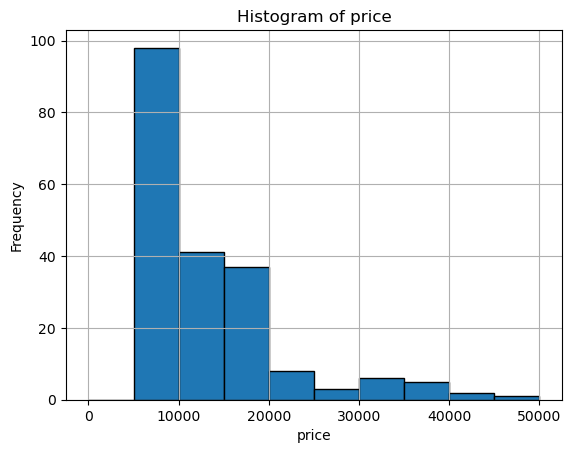

In [39]:

# Побудова гістограми для DataFrame
def draw_hist_df(df, col, bins_list):
    if col not in df.columns or not pd.api.types.is_numeric_dtype(df[col]):
        print(f"Column '{col}' is invalid or non-numeric")
        return
    plt.hist(df[col], bins=bins_list, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

draw_hist_df(raw_df, 'price', [i for i in range(0, 55000, 5000)])


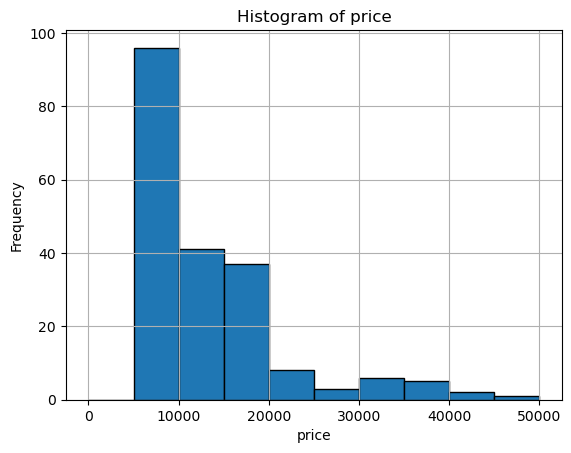

In [41]:
# Побудова гістограми для масиву
def draw_hist_array(arr, idx, bins, labels=None):
    try:
        values = arr[:, idx].astype(float)
    except ValueError:
        print("Invalid column for histogram")
        return

    label = next((k for k, v in labels.items() if v == idx), f'Index {idx}') if labels else f'Column {idx}'
    plt.hist(values, bins=bins, edgecolor='black')
    plt.title(f'Histogram of {label}')
    plt.xlabel(label)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

draw_hist_array(final_array, 0, [i for i in range(0, 55000, 5000)], column_map)


4. Збудувати графік залежності одного integer/real атрибута від іншого.

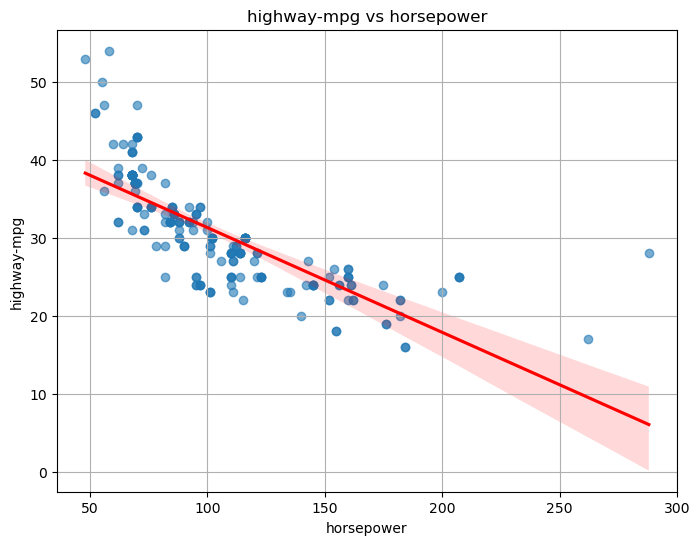

In [86]:
def regression_plot_df(df, x_col, y_col):
    if x_col not in df.columns or y_col not in df.columns:
        print("Invalid column names")
        return
    if not pd.api.types.is_numeric_dtype(df[x_col]) or not pd.api.types.is_numeric_dtype(df[y_col]):
        print("One of the columns is not numeric")
        return

    plt.figure(figsize=(8, 6))
    sns.regplot(data=df, x=x_col, y=y_col, scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
    plt.title(f'{y_col} vs {x_col}')
    plt.grid(True)
    plt.show()

regression_plot_df(raw_df, 'horsepower', 'highway-mpg')


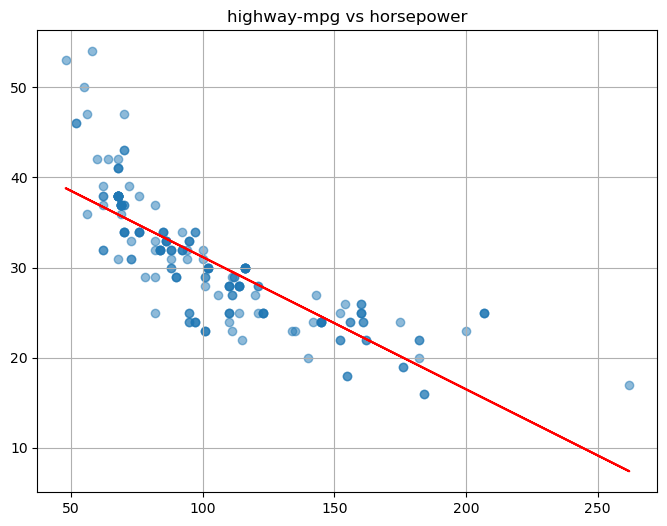

In [88]:
def regression_plot_array(arr, idx_x, idx_y, col_dict=None):
    try:
        x_vals = arr[:, idx_x].astype(float)
        y_vals = arr[:, idx_y].astype(float)
    except ValueError:
        print("Error converting data to float")
        return

    slope, intercept = np.polyfit(x_vals, y_vals, 1)
    predicted = slope * x_vals + intercept

    x_label = next((k for k, v in col_dict.items() if v == idx_x), str(idx_x)) if col_dict else str(idx_x)
    y_label = next((k for k, v in col_dict.items() if v == idx_y), str(idx_y)) if col_dict else str(idx_y)

    plt.figure(figsize=(8, 6))
    plt.scatter(x_vals, y_vals, alpha=0.5, label='Data')
    plt.plot(x_vals, predicted, color='red', label='Regression Line')
    plt.title(f'{y_label} vs {x_label}')
    plt.grid(True)
    plt.show()

regression_plot_array(final_array, column_map['horsepower'], column_map['highway-mpg'], column_map)

5. Підрахувати коефіцієнт Пірсона та Спірмена для двох integer/real
атрибутів.

In [67]:
#Pandas
def compute_correlations_df(df, col1, col2):
    """Обчислює коефіцієнти Пірсона і Спірмена між двома числовими колонками DataFrame."""
    # Вибір числових значень
    x = pd.to_numeric(df[col1], errors='coerce')
    y = pd.to_numeric(df[col2], errors='coerce')
    
    # Видалення пар з NaN
    mask = ~x.isna() & ~y.isna()
    x_clean = x[mask]
    y_clean = y[mask]

    # Обчислення кореляцій
    pearson_corr, _ = pearsonr(x_clean, y_clean)
    spearman_corr, _ = spearmanr(x_clean, y_clean)

    return pearson_corr, spearman_corr
pearson_df, spearman_df = compute_correlations_df(raw_df, "price", "horsepower")
print(f"DF - Pearson: {pearson_df:.4f}, Spearman: {spearman_df:.4f}")

def compute_correlations_array(array, idx1, idx2):
    """Обчислює коефіцієнти Пірсона і Спірмена між двома колонками NumPy-масиву."""
    x = array[:, idx1].astype(float)
    y = array[:, idx2].astype(float)
    
    # Фільтрація NaN
    valid_mask = ~np.isnan(x) & ~np.isnan(y)
    x_clean = x[valid_mask]
    y_clean = y[valid_mask]

    # Обчислення кореляцій
    pearson_corr, _ = pearsonr(x_clean, y_clean)
    spearman_corr, _ = spearmanr(x_clean, y_clean)

    return pearson_corr, spearman_corr

idx_price = column_map["price"]
idx_horsepower = column_map["horsepower"]
pearson_arr, spearman_arr = compute_correlations_array(final_array, idx_price, idx_horsepower)
print(f"Array - Pearson: {pearson_arr:.4f}, Spearman: {spearman_arr:.4f}")


DF - Pearson: 0.8105, Spearman: 0.8505
Array - Pearson: 0.8105, Spearman: 0.8505


6. Провести One Hot Encoding категоріального string атрибуту.

In [69]:
def one_hot_encode_column(
    df: pd.DataFrame,
    column_name: str,
    drop_original: bool = False
) -> pd.DataFrame:
    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in DataFrame.")
    df_copy = df.copy()
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoded_data = encoder.fit_transform(df_copy[[column_name]])
    encoded_columns = [f"{column_name}_{cat}" for cat in encoder.categories_[0]]
    encoded_df = pd.DataFrame(encoded_data, columns=encoded_columns, index=df_copy.index)
    df_encoded = pd.concat([df_copy, encoded_df], axis=1)
    if drop_original:
        df_encoded.drop(columns=[column_name], inplace=True)

    return df_encoded

encoded_df = one_hot_encode_column(raw_df, 'body-style')
print(encoded_df.head())

     price  highway-mpg  city-mpg  peak-rpm  horsepower  compression-ratio  \
0  13495.0           27        21    5000.0       111.0                9.0   
1  16500.0           27        21    5000.0       111.0                9.0   
2  16500.0           26        19    5000.0       154.0                9.0   
3  13950.0           30        24    5500.0       102.0               10.0   
4  17450.0           22        18    5500.0       115.0                8.0   

   stroke  bore fuel-system  engine-size  ...  num-of-doors aspiration  \
0    2.68  3.47        mpfi          130  ...           2.0        std   
1    2.68  3.47        mpfi          130  ...           2.0        std   
2    3.47  2.68        mpfi          152  ...           2.0        std   
3    3.40  3.19        mpfi          109  ...           4.0        std   
4    3.40  3.19        mpfi          136  ...           4.0        std   

   fuel-type         make  normalized-losses  body-style_convertible  \
0        gas  

In [71]:
import numpy as np

def one_hot_encode_column_numpy(array: np.ndarray, column_index: int, drop_original: bool = False):
    array_copy = array.copy()
    col_values = array_copy[:, column_index]
    unique_vals = np.unique(col_values)
    one_hot = np.zeros((array_copy.shape[0], len(unique_vals)), dtype=int)
    for i, val in enumerate(col_values):
        one_hot[i, np.where(unique_vals == val)[0][0]] = 1
    if drop_original:
        array_copy = np.delete(array_copy, column_index, axis=1)
    new_array = np.hstack((array_copy, one_hot.astype(str)))
    return new_array, unique_vals.tolist()
col_idx = column_map["body-style"]
encoded_array, categories = one_hot_encode_column_numpy(final_array, col_idx, drop_original=True)

print("One-hot encoded array:\n", encoded_array[:5])
print("Категорії:", categories)


One-hot encoded array:
 [[13495.0 27 21 5000.0 111.0 9.0 2.68 3.47 'mpfi' 130 4 'dohc' 2548 48.8
  64.1 168.8 88.6 'front' 'rwd' 2.0 'std' 'gas' 'alfa-romero' -1.0 '1'
  '0' '0' '0' '0']
 [16500.0 27 21 5000.0 111.0 9.0 2.68 3.47 'mpfi' 130 4 'dohc' 2548 48.8
  64.1 168.8 88.6 'front' 'rwd' 2.0 'std' 'gas' 'alfa-romero' -1.0 '1'
  '0' '0' '0' '0']
 [16500.0 26 19 5000.0 154.0 9.0 3.47 2.68 'mpfi' 152 6 'ohcv' 2823 52.4
  65.5 171.2 94.5 'front' 'rwd' 2.0 'std' 'gas' 'alfa-romero' -1.0 '0'
  '0' '1' '0' '0']
 [13950.0 30 24 5500.0 102.0 10.0 3.4 3.19 'mpfi' 109 4 'ohc' 2337 54.3
  66.2 176.6 99.8 'front' 'fwd' 4.0 'std' 'gas' 'audi' 164.0 '0' '0' '0'
  '1' '0']
 [17450.0 22 18 5500.0 115.0 8.0 3.4 3.19 'mpfi' 136 5 'ohc' 2824 54.3
  66.4 176.6 99.4 'front' '4wd' 4.0 'std' 'gas' 'audi' 164.0 '0' '0' '0'
  '1' '0']]
Категорії: ['convertible', 'hardtop', 'hatchback', 'sedan', 'wagon']


7. Провести візуалізацію багатовимірних даних, використовуючи приклади, наведені у медіумі - https://towardsdatascience.com/the-art-of-effective-visualization-of-multi-dimensional-data-6c7202990c57.

2D 

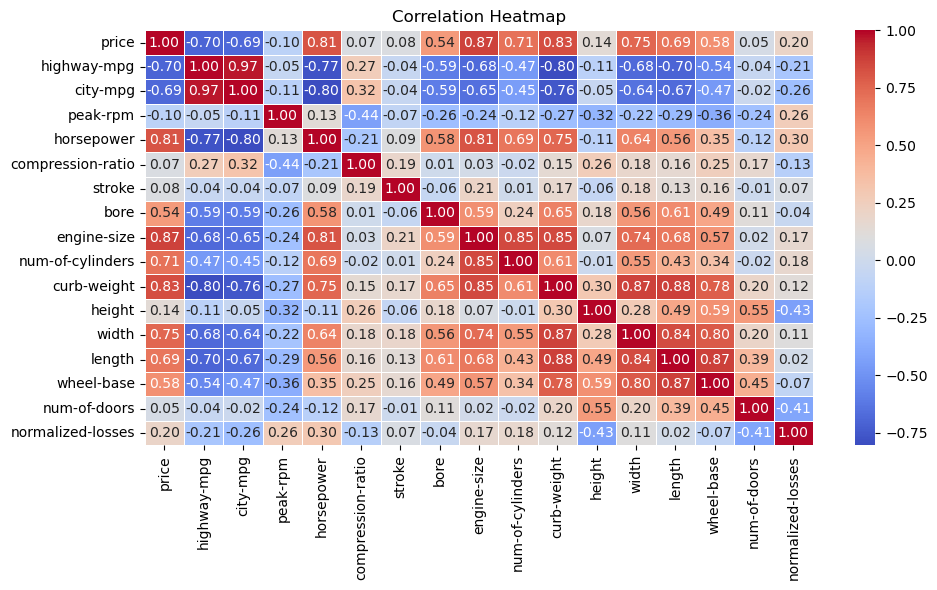

In [73]:
def plot_correlation_heatmap(df: pd.DataFrame, figsize=(10, 6), title="Correlation Heatmap"):
    numeric_df = df.select_dtypes(include=[float, int]).copy()
    corr_matrix = numeric_df.corr()
    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title(title)
    plt.tight_layout()
    plt.show()
plot_correlation_heatmap(raw_df)

3D

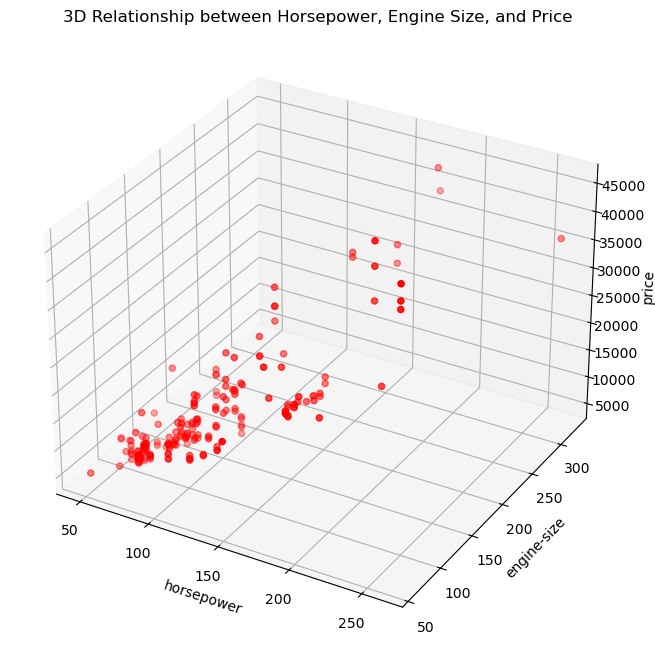

In [84]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
def plot_3d_scatter(df: pd.DataFrame, x_col: str, y_col: str, z_col: str, title: str = "3D Scatter Plot", color='r', marker='o'):
    xs = df[x_col]
    ys = df[y_col]
    zs = df[z_col]
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(xs, ys, zs, c=color, marker=marker)

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_zlabel(z_col)

    plt.title(title)
    plt.show()

plot_3d_scatter(raw_df, 'horsepower', 'engine-size', 'price', title="3D Relationship between Horsepower, Engine Size, and Price")

